# All-Features Model Exploration

Explores Logistic Regression (L1), SVM (RBF), Random Forest, and XGBoost on all 27 acoustic features from the proximity classification CSV.

Target: `IS_NEARBY` (≤10 ft, derived from DISTANCE). Evaluation: BCE, Brier Score, calibration curve, and predicted probability distribution.
- LR and SVM: in-sample `predict_proba` (low-capacity models, in-sample ≈ OOF)
- RF and XGBoost: `cross_val_predict` OOF probabilities (high-capacity, in-sample would be misleading)

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../..')  # repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
import xgboost as xgb

shap.initjs()
matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

## Data Loading

All H0 `RAW_` and `FILTERED_` columns are selected dynamically — no hardcoded feature list.

In [3]:
# ---- CONFIG ----
CSV_PATH     = '~/Documents/acoustics-v3/analysis/analysis_2026-04-25--13-14-47.csv'  # update path
THRESHOLD_FT = 10

# ---- Load ----
df = pd.read_csv(CSV_PATH)
df = df[df['ALL_VALID'] == True].reset_index(drop=True)

# Dynamically pick all H0 feature columns
feature_cols = sorted([c for c in df.columns
                       if c.startswith('H0 ') and ('RAW_' in c or 'FILTERED_' in c)])
short_names  = [c.replace('H0 ', '') for c in feature_cols]

X_raw = df[feature_cols].copy()
X_raw.columns = short_names

# Target: distance <= THRESHOLD_FT
y = (pd.to_numeric(df['DISTANCE'].str.replace('FT', ''), errors='coerce')
     <= THRESHOLD_FT).astype(int)

# Report and impute missing values with KNN (k=5 neighbours)
missing = X_raw.isna().sum()
if missing.any():
    print('Missing values before imputation:')
    print(missing[missing > 0].to_string())
imputer = KNNImputer(n_neighbors=5)
X_raw   = pd.DataFrame(imputer.fit_transform(X_raw), columns=short_names)
print(f'Missing values after imputation: {X_raw.isna().sum().sum()}')

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=short_names)

print(f'\nSamples  : {len(X_raw)}')
print(f'Features : {len(feature_cols)}')
print(f'Nearby (≤{THRESHOLD_FT}ft) : {(y==1).sum()}')
print(f'Far    (>{THRESHOLD_FT}ft) : {(y==0).sum()}')
X_raw.describe()

Missing values before imputation:
RAW_fwhm_ms           13
RAW_pulse_width_ms    13
RAW_rise_time_ms      13
Missing values after imputation: 0

Samples  : 447
Features : 52
Nearby (≤10ft) : 179
Far    (>10ft) : 268


,FILTERED_crest_factor,FILTERED_dynamic_range,FILTERED_early_late_ratio,FILTERED_early_window_energy,FILTERED_energy_concentration_pct,FILTERED_envelope_compactness,FILTERED_envelope_kurtosis,FILTERED_envelope_skewness,FILTERED_fall_time_ms,FILTERED_fwhm_ms,...,RAW_pulse_width_ms,RAW_rise_time_ms,RAW_secondary_peak_amplitude_ratio,RAW_secondary_peak_count,RAW_snr_db,RAW_spectral_bandwidth_hz,RAW_spectral_centroid_hz,RAW_spectral_flatness,RAW_time_to_secondary_peak_ms,RAW_total_energy
count,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,...,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000
mean,35.906427,2471.669694,35.724132,3773.116250,54.908564,0.983231,342.203316,17.333489,5.161057,3.119148,...,7.304938,2.878114,0.207843,3837.073826,20.429108,11041.154397,76401.906521,0.316102,17.133126,10165.477609
std,4.168456,1088.577007,37.148576,2555.769081,20.588599,0.040687,78.369605,1.953577,3.352067,1.248347,...,2.856273,1.458305,0.164656,2843.393537,14.104105,10377.385168,11425.546236,0.064707,15.638546,17596.831265
min,26.469655,9.496248,0.599831,260.564618,9.033746,0.494172,157.909083,11.847411,0.220160,0.486400,...,1.026560,0.143360,0.002356,105.000000,7.518614,0.000000,39003.720657,0.193966,3.582720,1592.363500
25%,33.282041,2013.468237,12.043635,1956.703501,39.315044,0.983857,286.019869,15.907318,2.716160,2.055040,...,5.315840,1.743360,0.106385,2466.000000,14.334450,153.786179,67118.933728,0.251678,9.125760,4142.244600
50%,35.409591,2626.873557,24.304438,2991.747487,53.146693,0.988241,338.779030,17.339622,4.308480,3.692800,...,6.634240,3.057920,0.157207,3389.000000,17.224499,5979.778849,78418.264474,0.323767,12.144640,6579.235000
75%,38.025024,3238.802980,45.501958,4951.801509,72.398318,0.990524,391.870445,18.651495,7.080960,3.916800,...,9.023488,4.026240,0.257434,4580.500000,22.163834,22484.963610,85133.593287,0.370688,22.032640,10598.540000
max,60.209297,4480.046749,247.795949,13712.783699,95.519647,0.994318,790.285343,25.100766,16.989440,6.183680,...,17.149440,6.173440,0.973568,23900.000000,97.426010,22707.829254,96663.783921,0.450441,199.618560,135723.980000


## Correlation Matrix

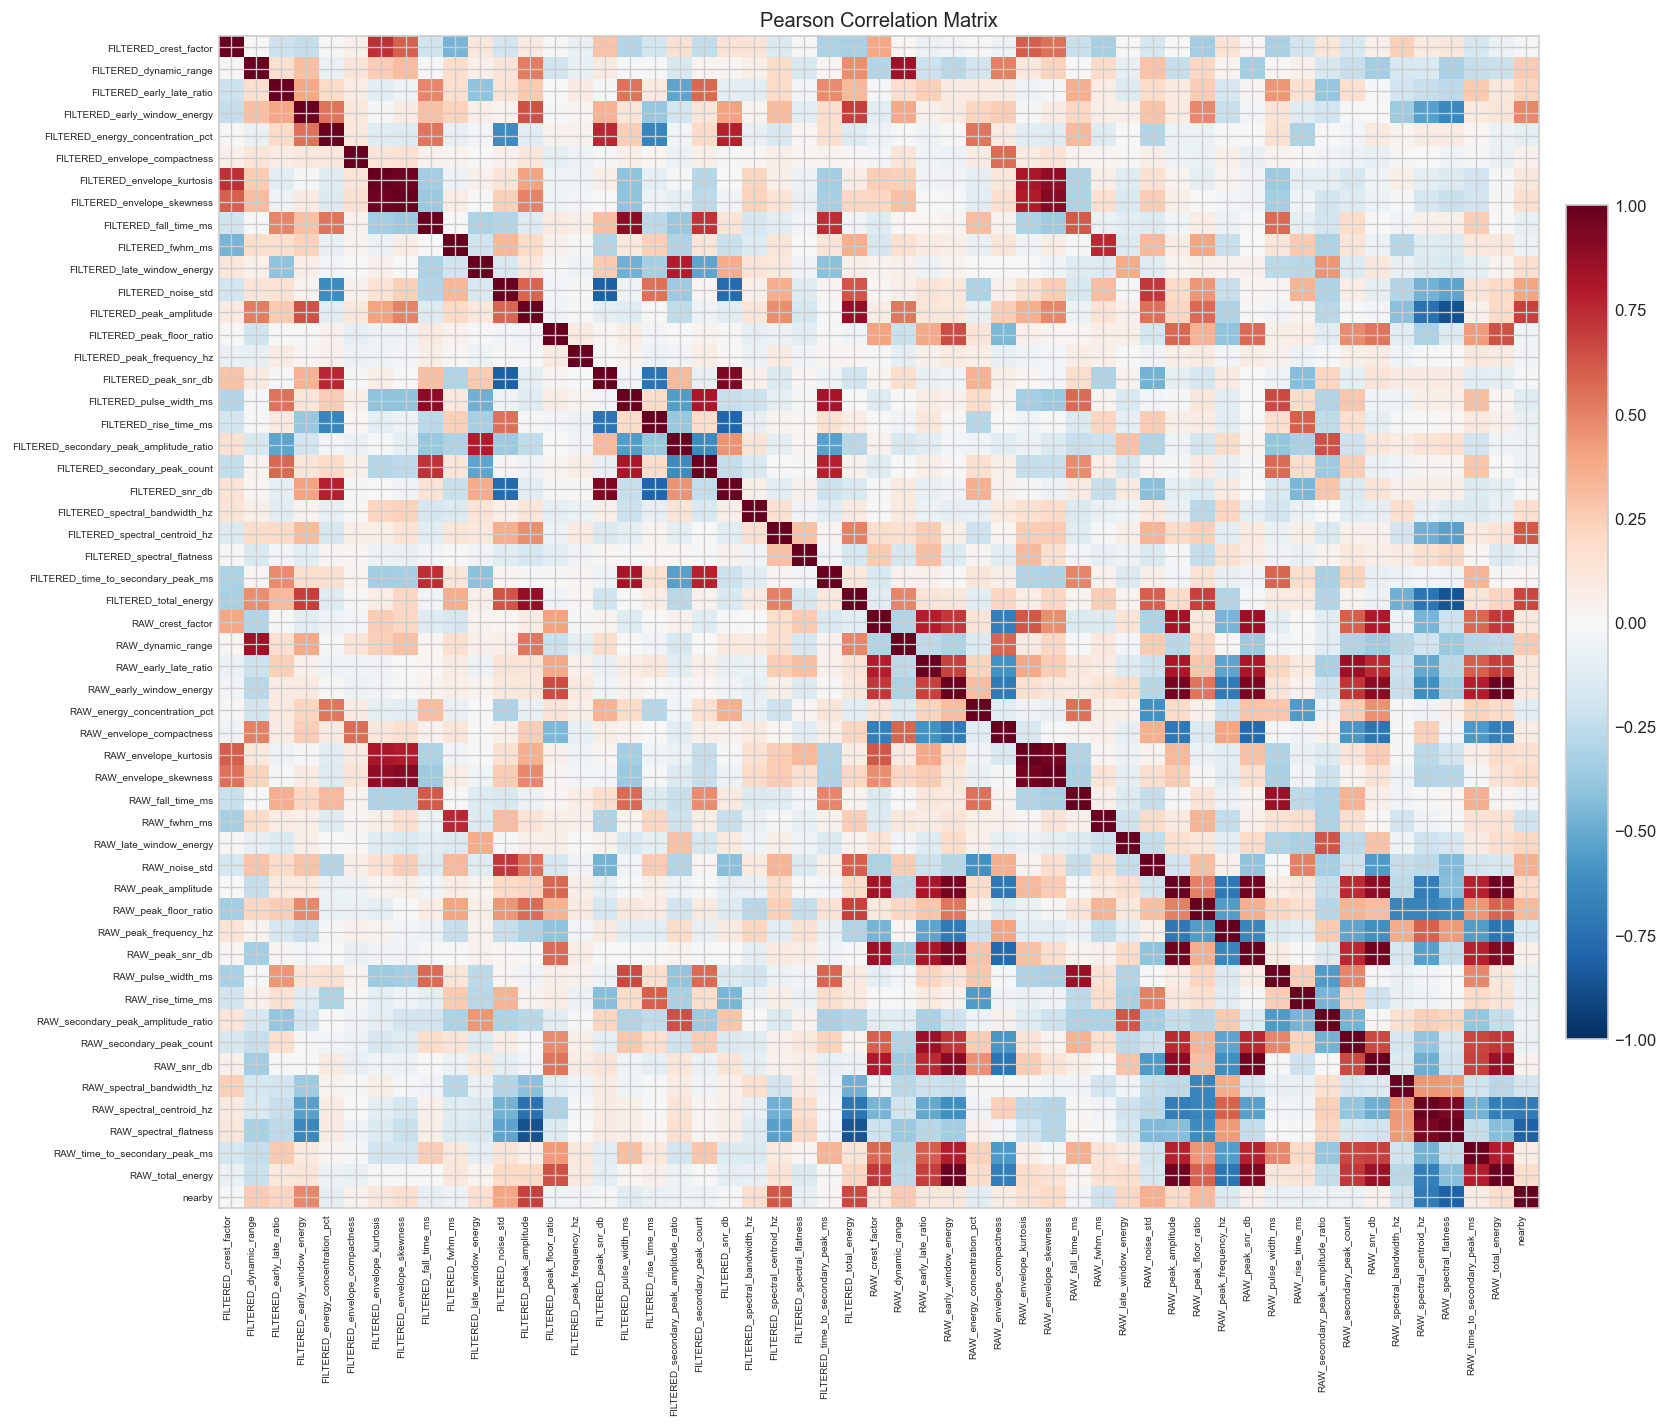

Feature–target correlations (|r| sorted):
RAW_spectral_flatness                     -0.807495
RAW_spectral_centroid_hz                  -0.703017
FILTERED_peak_amplitude                    0.682740
FILTERED_total_energy                      0.668465
FILTERED_spectral_centroid_hz              0.620169
FILTERED_early_window_energy               0.484162
FILTERED_noise_std                         0.394006
RAW_noise_std                              0.355767
RAW_peak_floor_ratio                       0.323265
RAW_dynamic_range                          0.259966
FILTERED_dynamic_range                     0.257594
FILTERED_early_late_ratio                  0.217482
RAW_fwhm_ms                               -0.209086
RAW_late_window_energy                     0.204822
RAW_envelope_skewness                      0.202667
RAW_peak_amplitude                         0.188950
RAW_spectral_bandwidth_hz                 -0.183839
RAW_total_energy                           0.174959
FILTERED_late_window_e

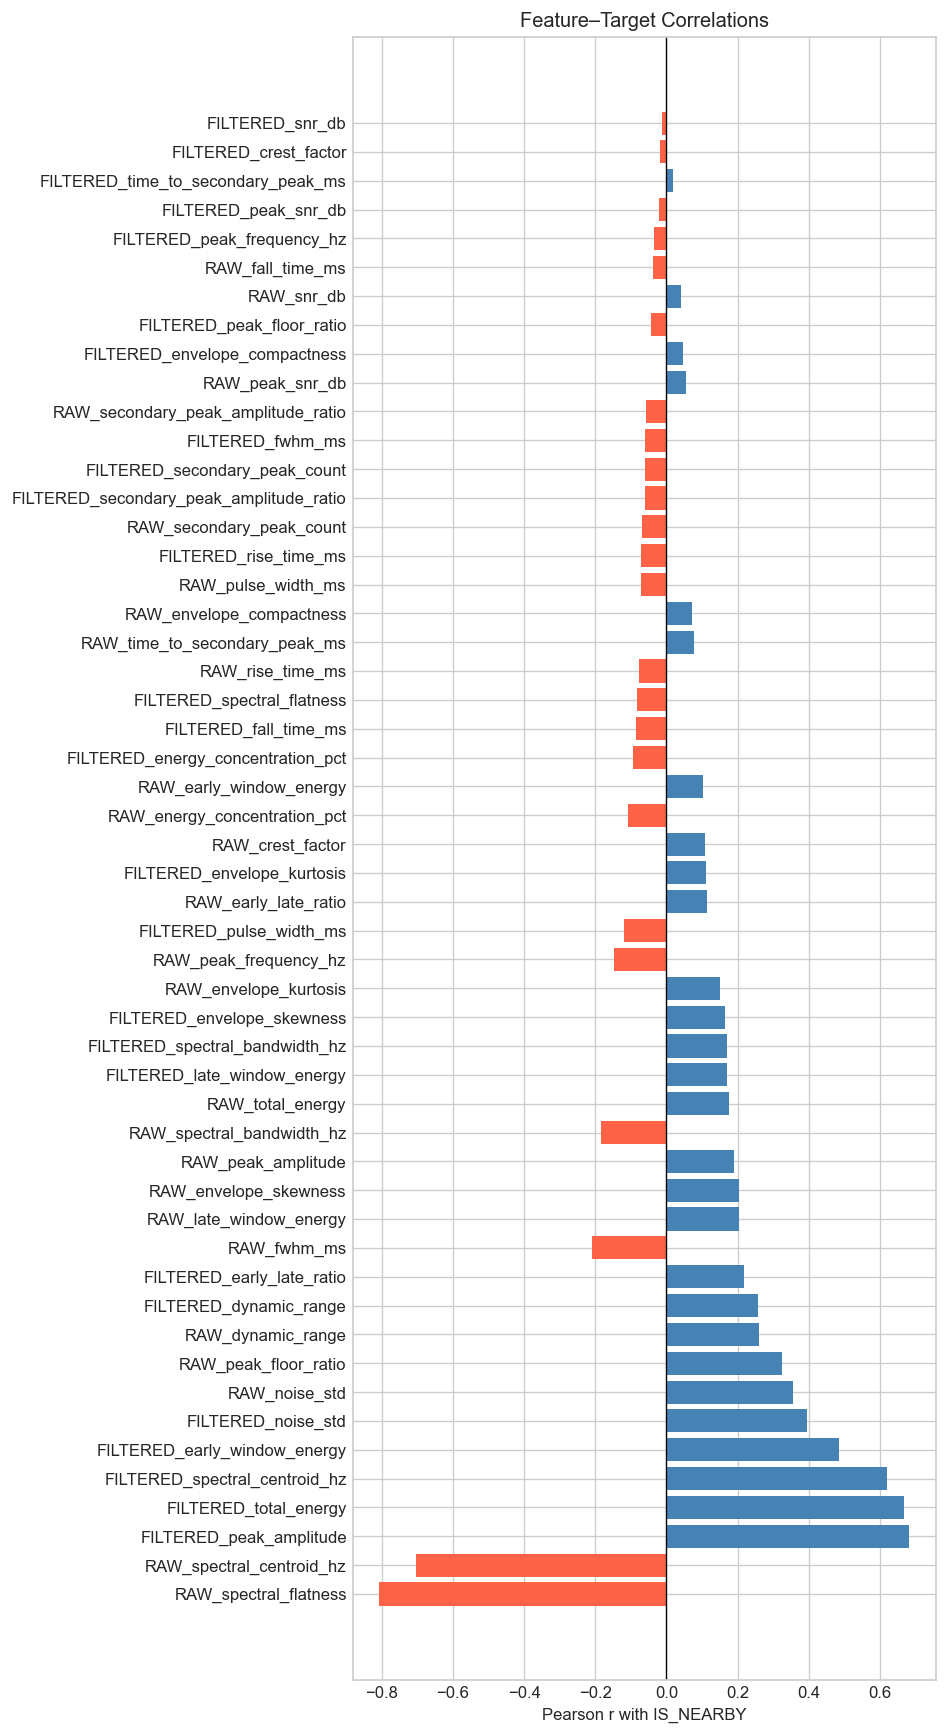

In [4]:
corr_df = X_raw.copy()
corr_df['nearby'] = y.values
corr = corr_df.corr()

# Feature–feature heatmap (no text labels — too many to annotate)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
labels = short_names + ['nearby']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=6)
ax.set_yticklabels(labels, fontsize=6)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

# Feature–target correlations sorted by |r|
target_corr = corr['nearby'].drop('nearby').sort_values(key=abs, ascending=False)
print('Feature–target correlations (|r| sorted):')
print(target_corr.to_string())

fig, ax = plt.subplots(figsize=(8, max(4, len(short_names) * 0.28)))
colors = ['steelblue' if v >= 0 else 'tomato' for v in target_corr]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with IS_NEARBY')
ax.set_title('Feature–Target Correlations')
plt.tight_layout()
plt.show()

## PCA

Loadings table shows each feature's contribution to each principal component. Bar charts visualise the top-4 components.

PCA Loadings and Explained Variance:
      FILTERED_crest_factor  FILTERED_dynamic_range  FILTERED_early_late_ratio  FILTERED_early_window_energy  FILTERED_energy_concentration_pct  FILTERED_envelope_compactness  FILTERED_envelope_kurtosis  FILTERED_envelope_skewness  FILTERED_fall_time_ms  FILTERED_fwhm_ms  FILTERED_late_window_energy  FILTERED_noise_std  FILTERED_peak_amplitude  FILTERED_peak_floor_ratio  FILTERED_peak_frequency_hz  FILTERED_peak_snr_db  FILTERED_pulse_width_ms  FILTERED_rise_time_ms  FILTERED_secondary_peak_amplitude_ratio  FILTERED_secondary_peak_count  FILTERED_snr_db  FILTERED_spectral_bandwidth_hz  FILTERED_spectral_centroid_hz  FILTERED_spectral_flatness  FILTERED_time_to_secondary_peak_ms  FILTERED_total_energy  RAW_crest_factor  RAW_dynamic_range  RAW_early_late_ratio  RAW_early_window_energy  RAW_energy_concentration_pct  RAW_envelope_compactness  RAW_envelope_kurtosis  RAW_envelope_skewness  RAW_fall_time_ms  RAW_fwhm_ms  RAW_late_window_energy  RAW_noise_s

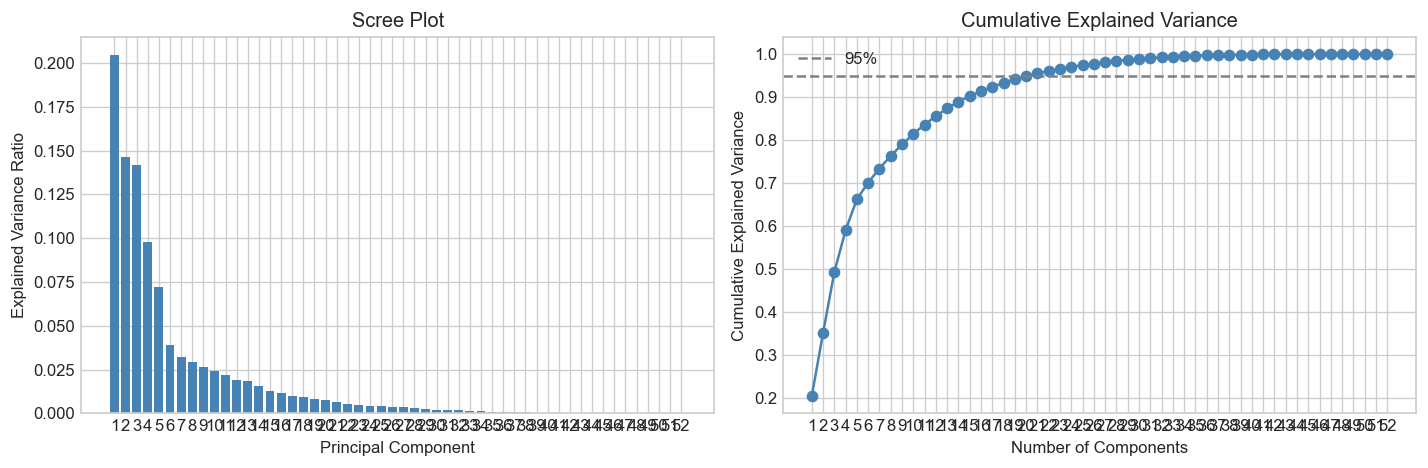

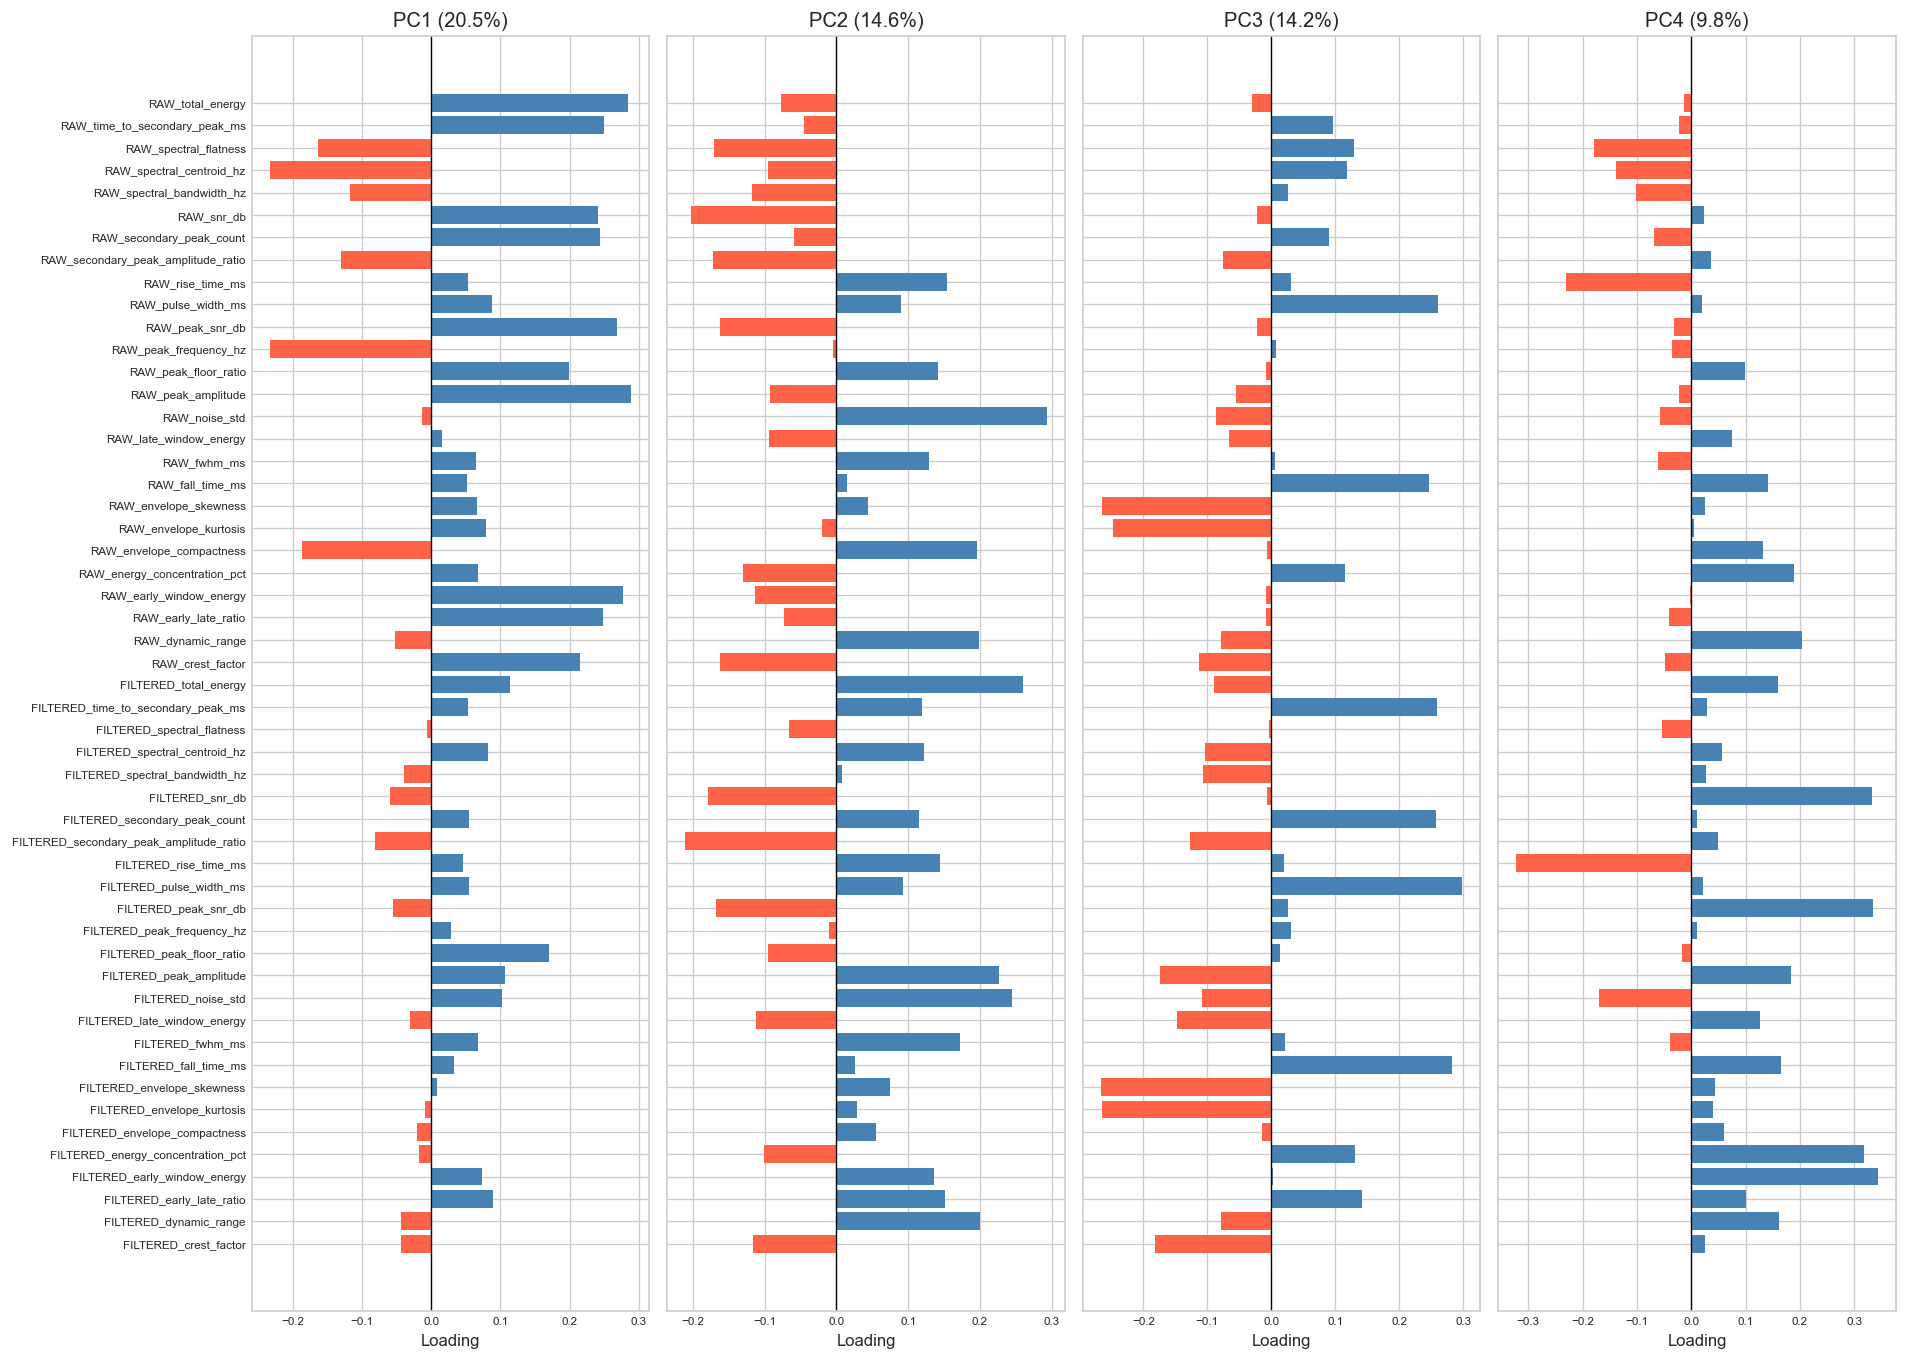

In [5]:
pca = PCA()
pca.fit(X_scaled)

# Loadings + explained variance table
loadings = pd.DataFrame(
    pca.components_,
    index=[f'PC{i+1}' for i in range(pca.n_components_)],
    columns=short_names,
)
loadings['explained_var_ratio'] = pca.explained_variance_ratio_
loadings['cumulative_var']      = pca.explained_variance_ratio_.cumsum()
print('PCA Loadings and Explained Variance:')
print(loadings.to_string(float_format='{:.4f}'.format))

# Scree + cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, pca.n_components_+1))

axes[1].plot(range(1, pca.n_components_+1), pca.explained_variance_ratio_.cumsum(),
             'o-', color='steelblue')
axes[1].axhline(0.95, linestyle='--', color='gray', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, pca.n_components_+1))
axes[1].legend()
plt.tight_layout()
plt.show()

# Bar chart of loadings for first 4 PCs
n_show = min(4, pca.n_components_)
fig, axes = plt.subplots(1, n_show,
                         figsize=(4 * n_show, max(4, len(short_names) * 0.22)),
                         sharey=True)
for i, ax in enumerate(np.atleast_1d(axes)):
    comp   = pca.components_[i]
    colors = ['steelblue' if v >= 0 else 'tomato' for v in comp]
    ax.barh(short_names, comp, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
    ax.set_xlabel('Loading')
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

## Evaluation Helper

`evaluate_model` prints **BCE (log-loss)** and **Brier Score**, then plots:
- **Calibration curve**: quantile bins so each bin is equally populated
- **Predicted probability distribution**: density split by actual class

In [6]:
def evaluate_model(name, y_true, y_prob):
    bce   = log_loss(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    print(f'{name}  |  BCE (log-loss): {bce:.4f}   Brier Score: {brier:.4f}')

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    # Calibration curve — quantile bins keep each bin equally populated
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='quantile')
    axes[0].plot(prob_pred, prob_true, 's-', color='steelblue', label=name)
    axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[0].set_xlabel('Mean predicted probability')
    axes[0].set_ylabel('Fraction of positives')
    axes[0].set_title(f'{name} — Calibration Curve')
    axes[0].legend(loc='upper left')

    # Predicted probability distribution split by actual class
    axes[1].hist(y_prob[y_true == 0], bins=20, alpha=0.6, color='tomato',
                 label='Far (0)', density=True)
    axes[1].hist(y_prob[y_true == 1], bins=20, alpha=0.6, color='steelblue',
                 label='Nearby (1)', density=True)
    axes[1].set_xlabel('Predicted probability  P(nearby=1)')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'{name} — Predicted Probability Distribution')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## Logistic Regression (L1-regularized)

L1 penalty drives irrelevant coefficients to exactly zero. `C` selected via 5-fold stratified CV minimising log-loss. In-sample `predict_proba` used for evaluation (low-capacity model — in-sample ≈ OOF).

Best C (1/λ, larger = less regularization): 1.1242
LR  CV Accuracy: 97.10% ± 1.66%

Non-zero coefficients: 18 / 52

Logistic Regression Coefficients (L1, z-scored features):
                                feature  coefficient
                  RAW_spectral_flatness    -6.843069
          FILTERED_spectral_centroid_hz     2.318820
                      RAW_dynamic_range    -1.637368
               RAW_secondary_peak_count    -1.397988
                            RAW_fwhm_ms    -1.088111
                  FILTERED_crest_factor     1.039147
                 FILTERED_dynamic_range     0.630969
              RAW_spectral_bandwidth_hz     0.612530
                  RAW_envelope_kurtosis    -0.514309
                          RAW_noise_std    -0.468356
     FILTERED_time_to_secondary_peak_ms     0.408259
                       RAW_total_energy    -0.332684
                  RAW_envelope_skewness    -0.314344
              FILTERED_peak_floor_ratio    -0.176170
             FILTERED_envelope_

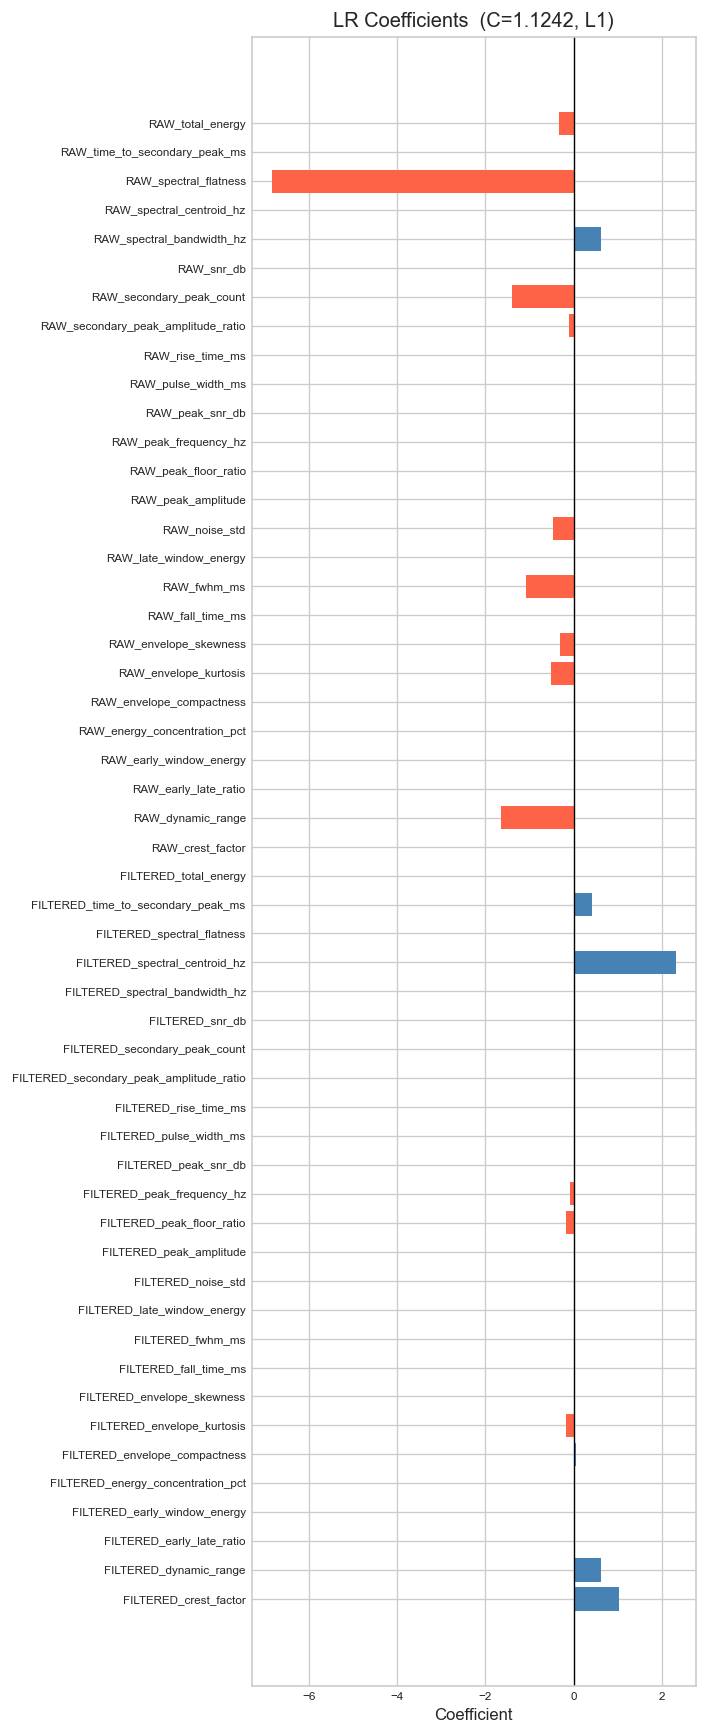

Logistic Regression  |  BCE (log-loss): 0.0461   Brier Score: 0.0119


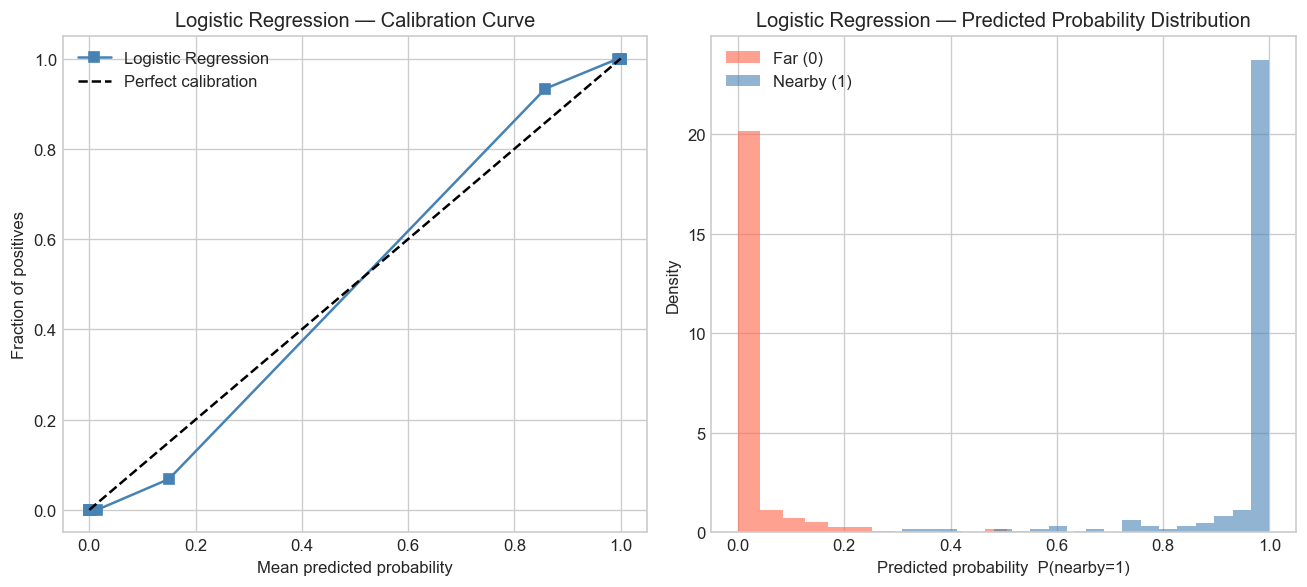

In [7]:
Cs    = np.logspace(-3, 3, 60)
cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid={'C': Cs},
    cv=cv_lr,
    scoring='neg_log_loss',
    n_jobs=-1,
)
lr_grid.fit(X_scaled, y)
lr     = lr_grid.best_estimator_
best_C = lr_grid.best_params_['C']
print(f'Best C (1/λ, larger = less regularization): {best_C:.4f}')

cv_acc = cross_val_score(lr, X_scaled, y, cv=cv_lr, scoring='accuracy')
print(f'LR  CV Accuracy: {cv_acc.mean():.2%} ± {cv_acc.std():.2%}')

# Coefficients table
coef_df = pd.DataFrame({'feature': short_names, 'coefficient': lr.coef_[0]})
coef_df['abs'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False).drop(columns='abs')
print(f'\nNon-zero coefficients: {(lr.coef_[0] != 0).sum()} / {len(short_names)}')
print('\nLogistic Regression Coefficients (L1, z-scored features):')
print(coef_df.to_string(index=False))

# Formula (only non-zero terms)
b0 = lr.intercept_[0]
print(f'\nFormula (z-scored features, zero terms omitted):')
print(f'  P(nearby=1) = σ(z)')
print(f'  z = {b0:+.4f}')
for c, f in zip(lr.coef_[0], short_names):
    if c != 0:
        print(f'      {c:+.4f} · {f}')
print(f'  σ(z) = 1 / (1 + exp(-z))')

# Coefficient bar chart
fig, ax = plt.subplots(figsize=(6, max(3, len(short_names) * 0.28)))
colors = ['steelblue' if c >= 0 else 'tomato' for c in lr.coef_[0]]
ax.barh(short_names, lr.coef_[0], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title(f'LR Coefficients  (C={best_C:.4f}, L1)')
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

lr_prob = lr.predict_proba(X_scaled)[:, 1]
evaluate_model('Logistic Regression', y, lr_prob)

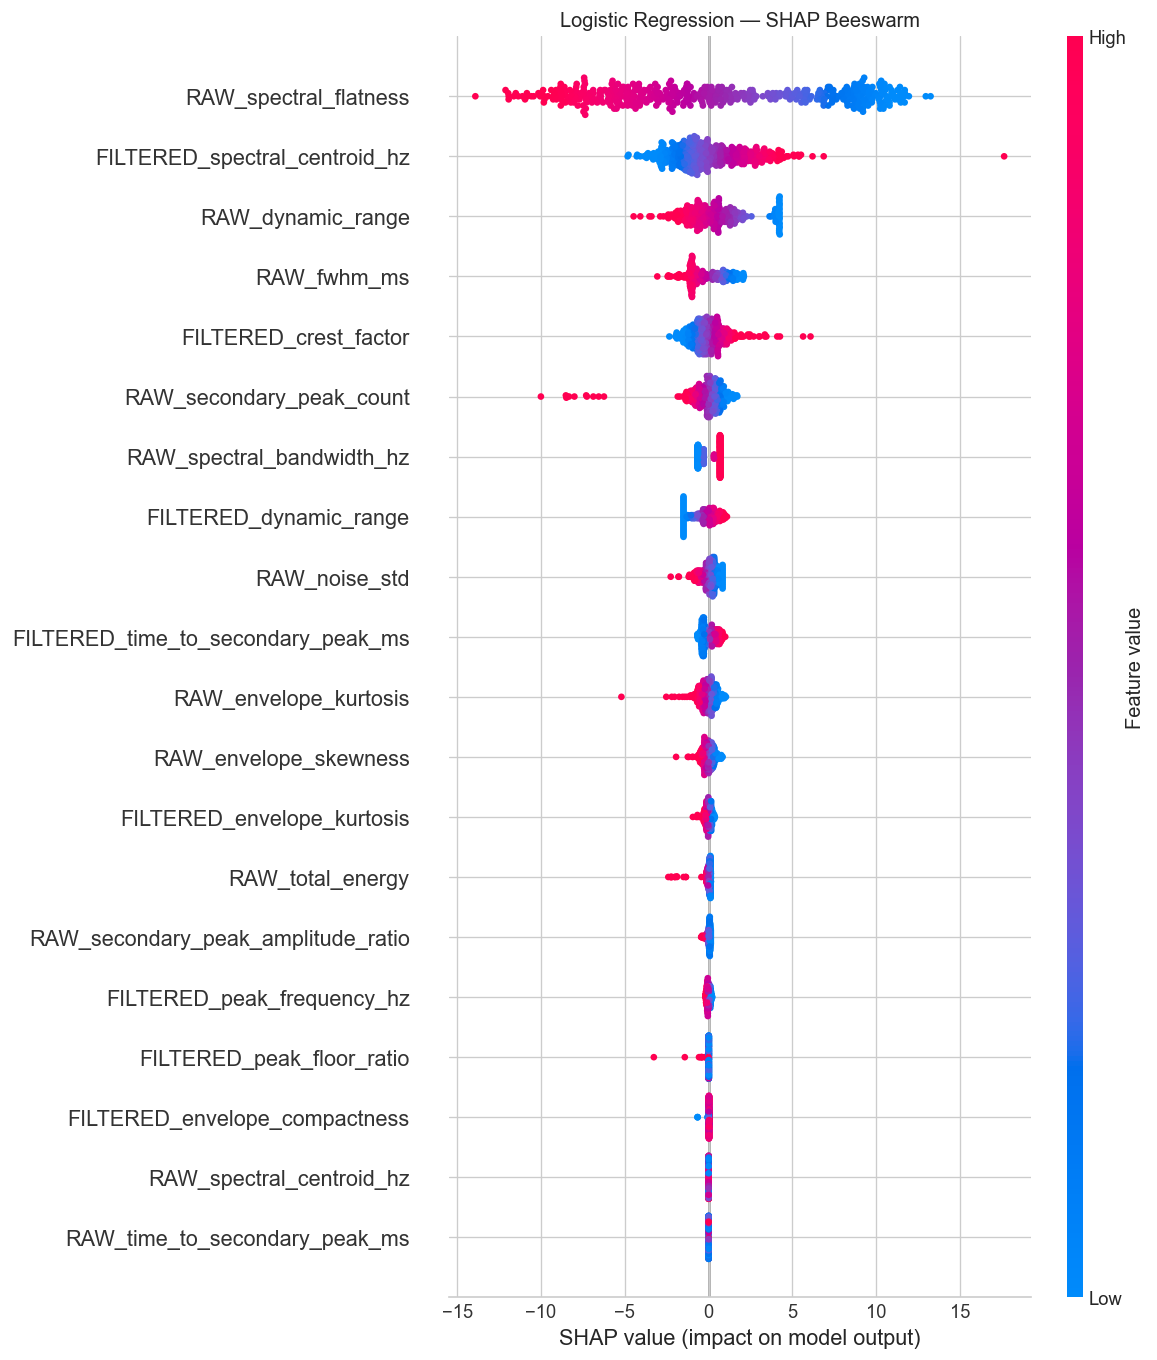

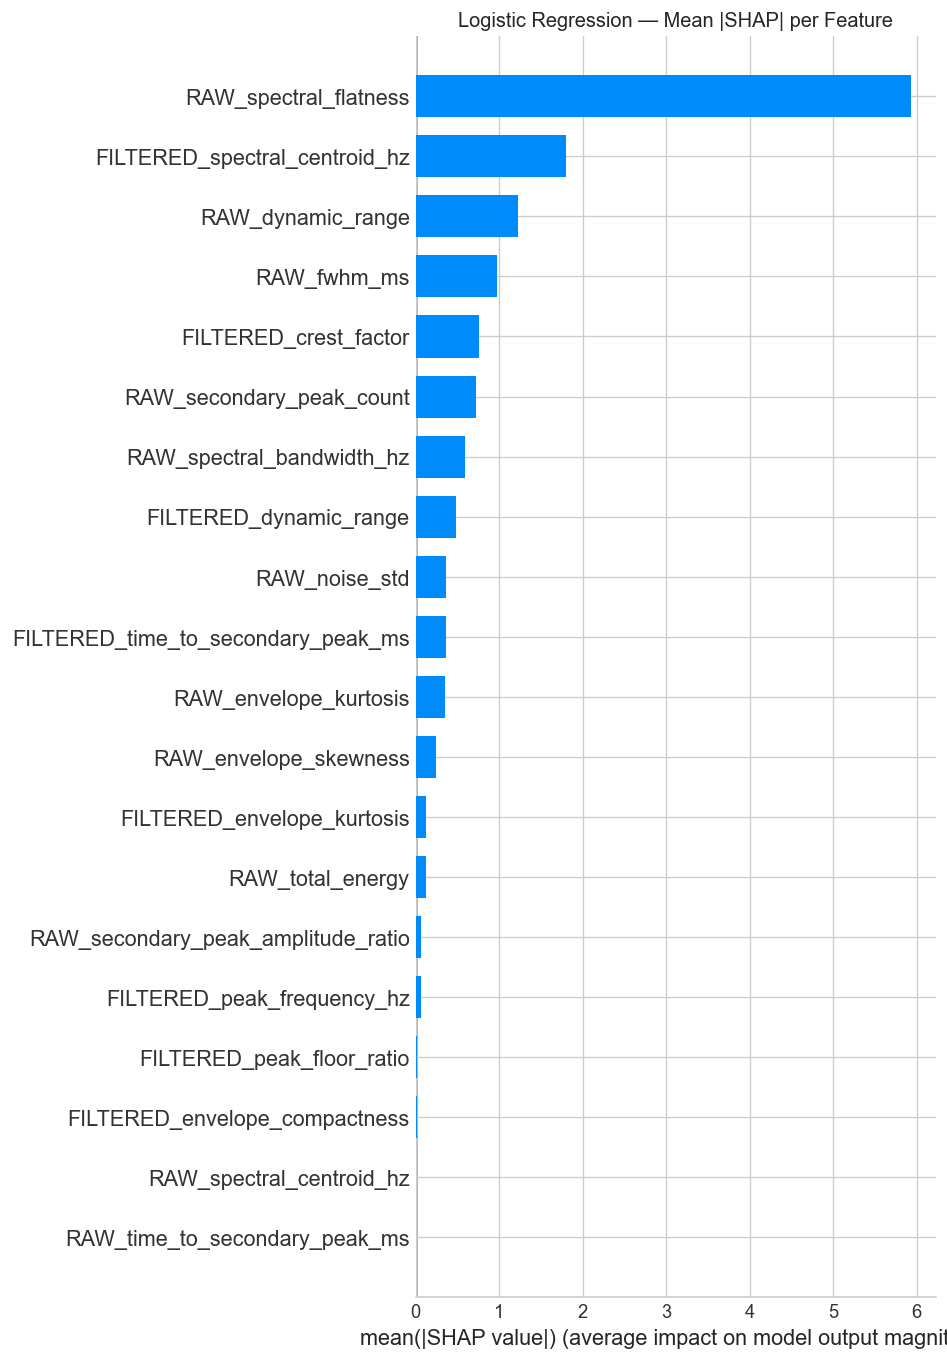

In [8]:
# SHAP — Logistic Regression (LinearExplainer: exact, fast)
explainer_lr = shap.LinearExplainer(lr, X_scaled)
shap_lr      = explainer_lr.shap_values(X_scaled)

shap.summary_plot(shap_lr, X_scaled, feature_names=short_names,
                  plot_size=(10, max(4, len(short_names) * 0.22)), show=False)
plt.title('Logistic Regression — SHAP Beeswarm')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_lr, X_scaled, feature_names=short_names, plot_type='bar',
                  plot_size=(8, max(4, len(short_names) * 0.22)), show=False)
plt.title('Logistic Regression — Mean |SHAP| per Feature')
plt.tight_layout()
plt.show()

## SVM (RBF Kernel)

RBF kernel SVM with Platt scaling. `C` and `γ` selected via 5-fold stratified CV minimising log-loss. In-sample `predict_proba` used for evaluation.

Best SVM params: {'C': 10, 'gamma': 0.01}
SVM  CV Accuracy: 96.43% ± 1.90%
SVM (RBF)  |  BCE (log-loss): 0.0132   Brier Score: 0.0018


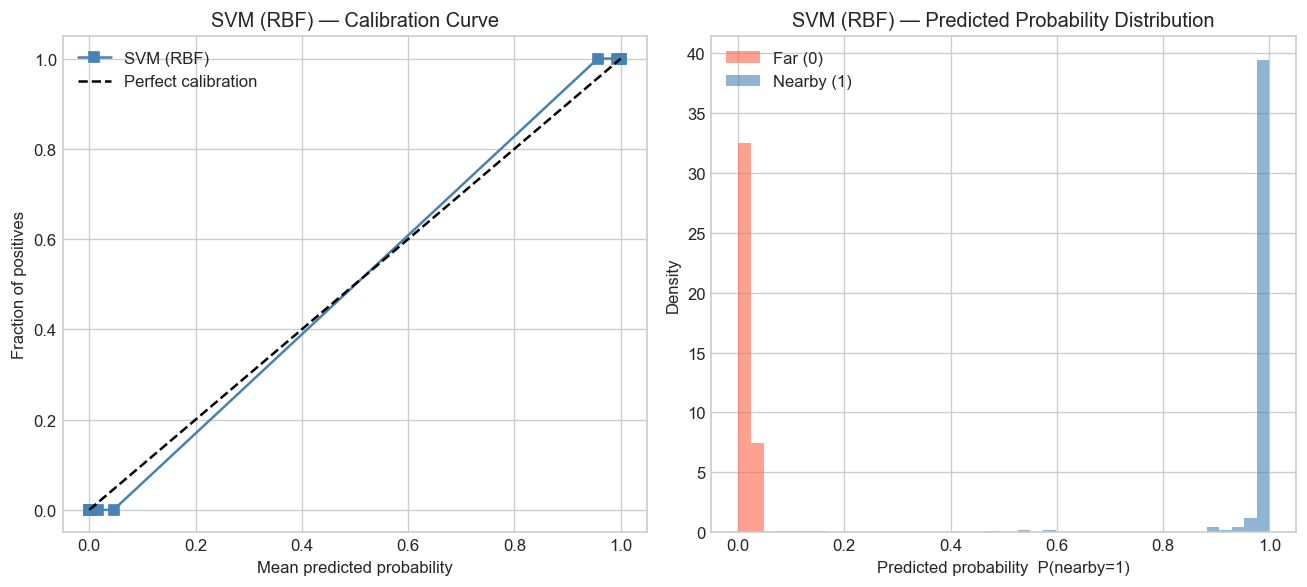

In [9]:
svm_param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
}
svm_cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    svm_param_grid,
    cv=svm_cv,
    scoring='neg_log_loss',
    n_jobs=-1,
)
svm_grid.fit(X_scaled, y)
svm = svm_grid.best_estimator_
print(f'Best SVM params: {svm_grid.best_params_}')

cv_svm = cross_val_score(svm, X_scaled, y, cv=svm_cv, scoring='accuracy')
print(f'SVM  CV Accuracy: {cv_svm.mean():.2%} ± {cv_svm.std():.2%}')

svm_prob = svm.predict_proba(X_scaled)[:, 1]
evaluate_model('SVM (RBF)', y, svm_prob)

Computing SVM SHAP values for 50 samples (KernelExplainer is slow)...


100%|██████████| 50/50 [00:05<00:00,  9.61it/s]


shap_svm_pos shape: (50, 52)   X_explain shape: (50, 52)


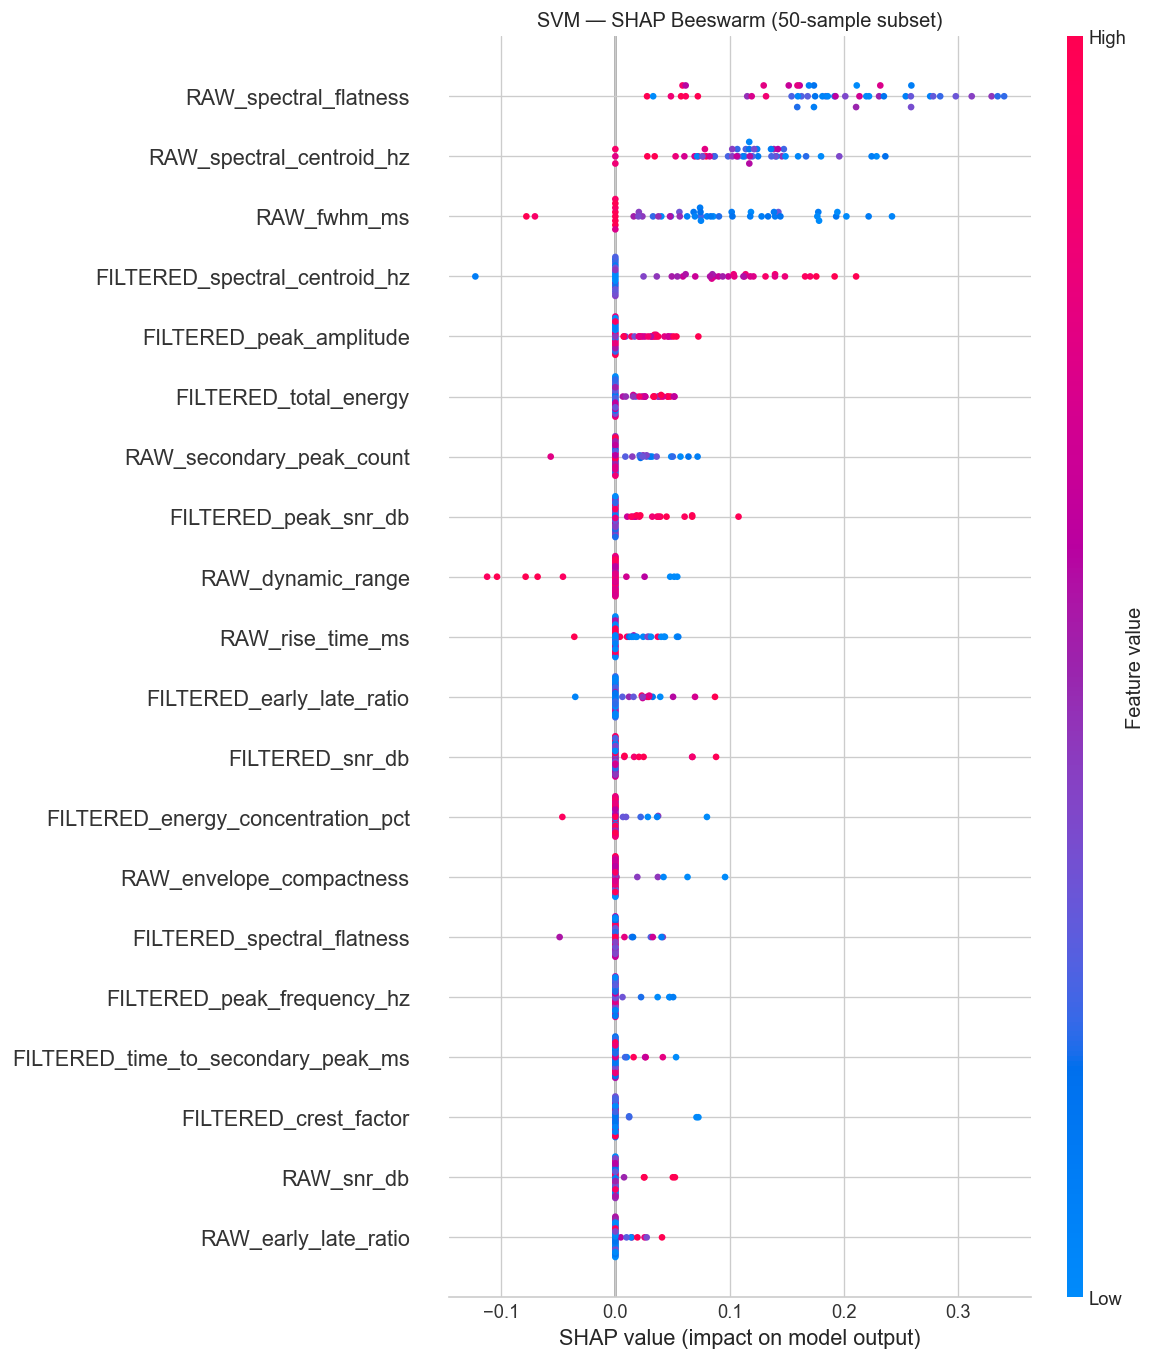

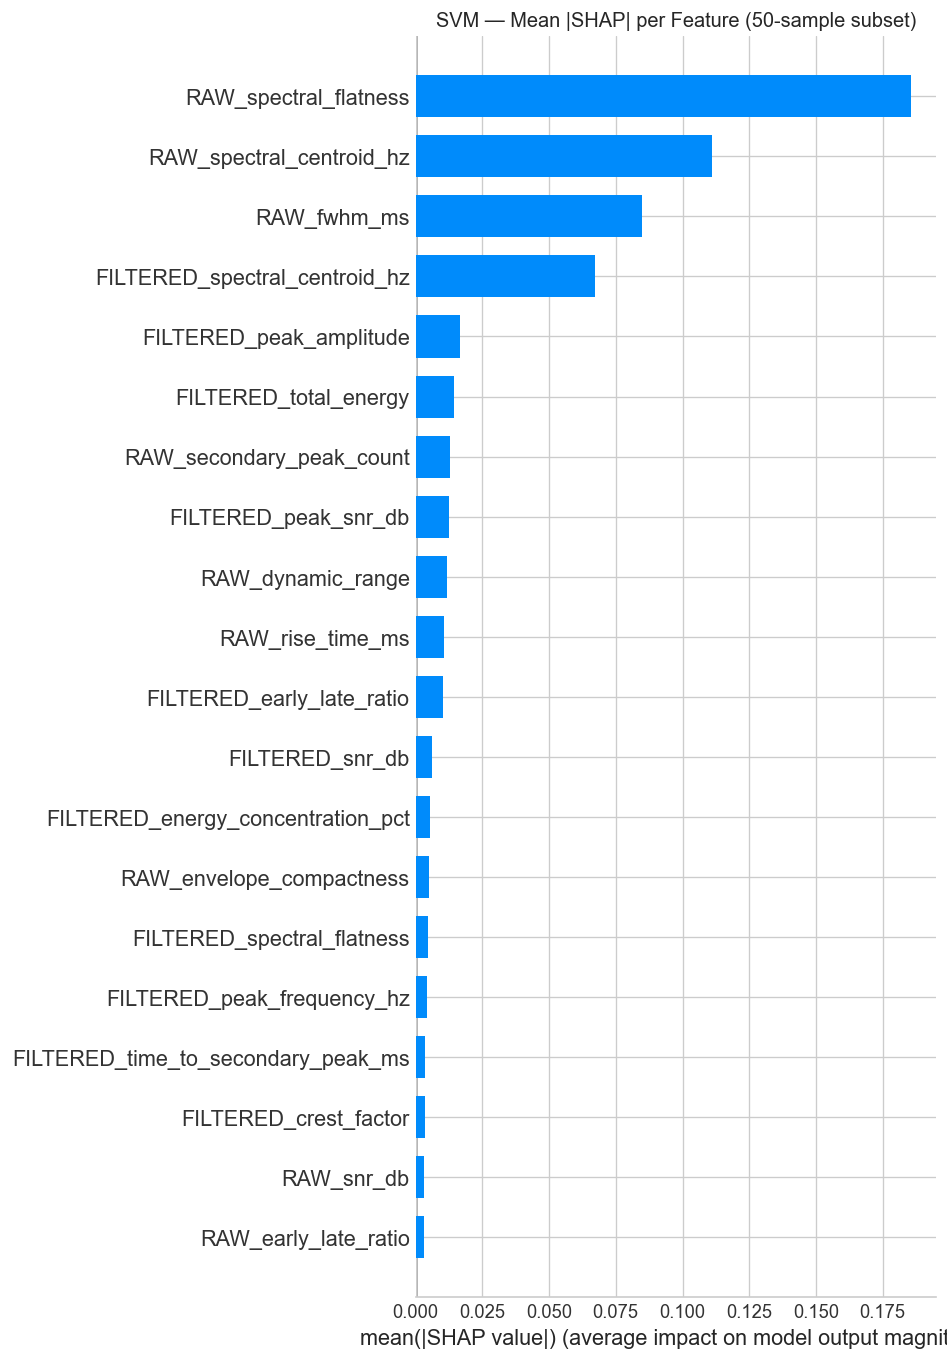

In [26]:
# SHAP — SVM (KernelExplainer: model-agnostic, slow — uses kmeans background + subset)
X_explain  = X_scaled.iloc[:50].to_numpy()
background = shap.kmeans(X_scaled.to_numpy(), 25)
explainer_svm = shap.KernelExplainer(lambda x: svm.predict_proba(x)[:, 1], background)
print('Computing SVM SHAP values for 50 samples (KernelExplainer is slow)...')
shap_svm_pos = explainer_svm.shap_values(X_explain, nsamples=200)

# Normalise: some SHAP versions wrap single-output in a list
if isinstance(shap_svm_pos, list):
    shap_svm_pos = shap_svm_pos[0]
shap_svm_pos = np.array(shap_svm_pos)
print(f'shap_svm_pos shape: {shap_svm_pos.shape}   X_explain shape: {X_explain.shape}')

shap.summary_plot(shap_svm_pos, X_explain, feature_names=short_names,
                  plot_size=(10, max(4, len(short_names) * 0.22)), show=False)
plt.title('SVM — SHAP Beeswarm (50-sample subset)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_svm_pos, X_explain, feature_names=short_names, plot_type='bar',
                  plot_size=(8, max(4, len(short_names) * 0.22)), show=False)
plt.title('SVM — Mean |SHAP| per Feature (50-sample subset)')
plt.tight_layout()
plt.show()

## Random Forest

OOF probabilities via `cross_val_predict` — avoids the degenerate calibration caused by in-sample leaf-memorisation.

Random Forest  CV Accuracy: 93.74% ± 2.29%

Feature Importances:
                                feature  importance
               RAW_spectral_centroid_hz    0.186449
                  RAW_spectral_flatness    0.140968
                     RAW_peak_amplitude    0.079708
                  FILTERED_total_energy    0.077650
          FILTERED_spectral_centroid_hz    0.075521
                       RAW_total_energy    0.052922
                FILTERED_peak_amplitude    0.050702
                      RAW_dynamic_range    0.026507
                            RAW_fwhm_ms    0.022741
                RAW_early_window_energy    0.021441
                       FILTERED_fwhm_ms    0.019103
                          RAW_noise_std    0.015846
           FILTERED_early_window_energy    0.014123
                     FILTERED_noise_std    0.014095
                       RAW_rise_time_ms    0.010954
               RAW_secondary_peak_count    0.010879
                   RAW_peak_floor_ratio    0.009577

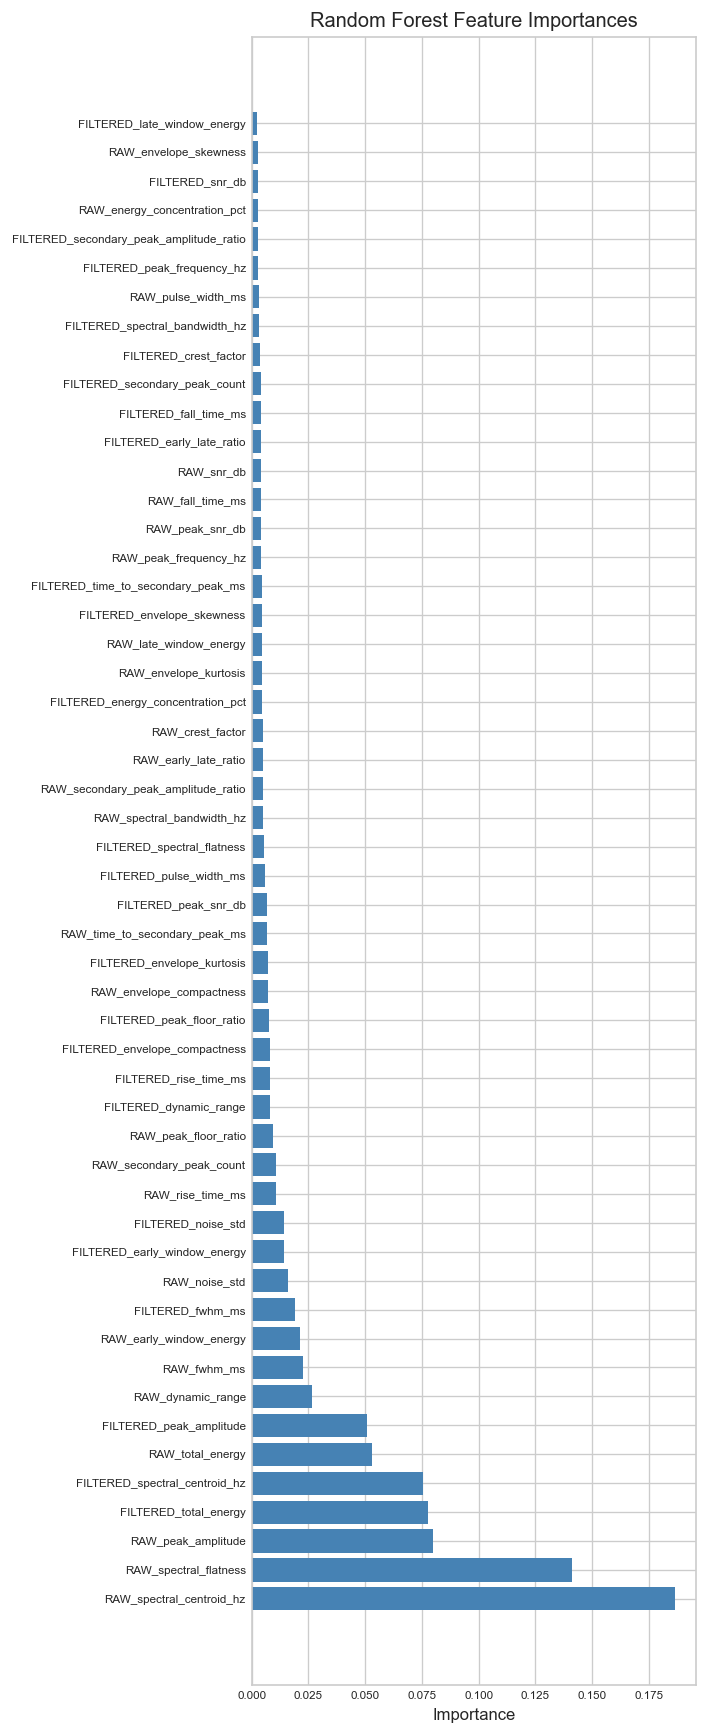

Random Forest (OOF)  |  BCE (log-loss): 0.1681   Brier Score: 0.0458


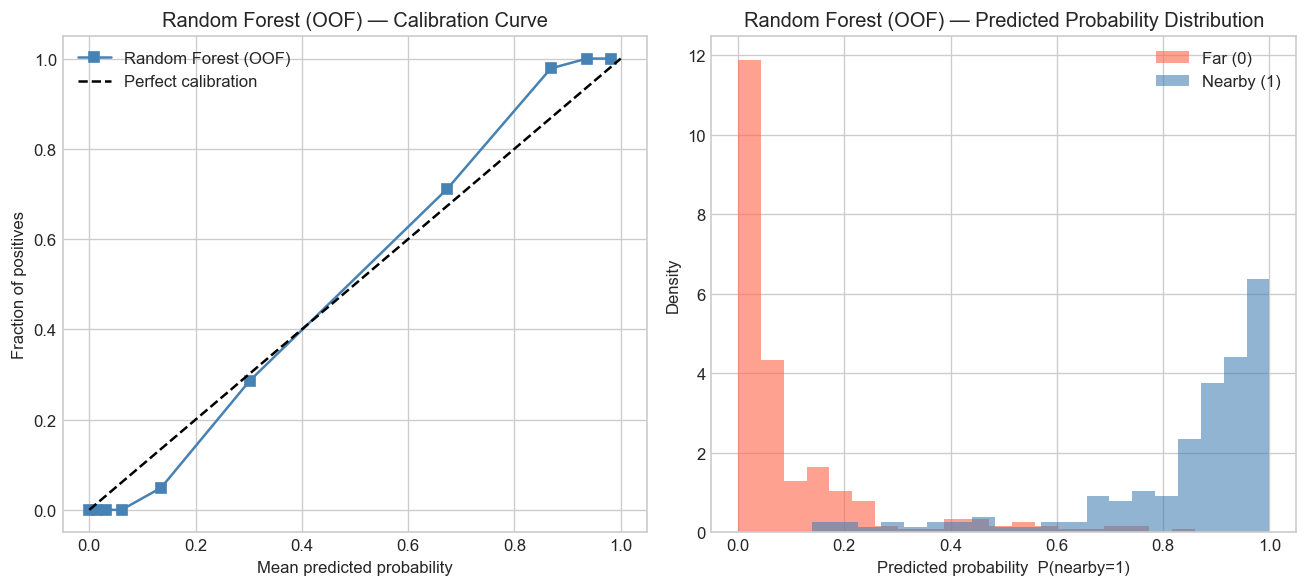

In [11]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_raw, y)

cv_rf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_scores = cross_val_score(rf, X_raw, y, cv=cv_rf, scoring='accuracy')
print(f'Random Forest  CV Accuracy: {rf_scores.mean():.2%} ± {rf_scores.std():.2%}')

imp_df = pd.DataFrame({'feature': short_names, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False)
print('\nFeature Importances:')
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, max(4, len(short_names) * 0.28)))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances')
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

rf_prob = cross_val_predict(rf, X_raw, y, cv=cv_rf, method='predict_proba')[:, 1]
evaluate_model('Random Forest (OOF)', y, rf_prob)

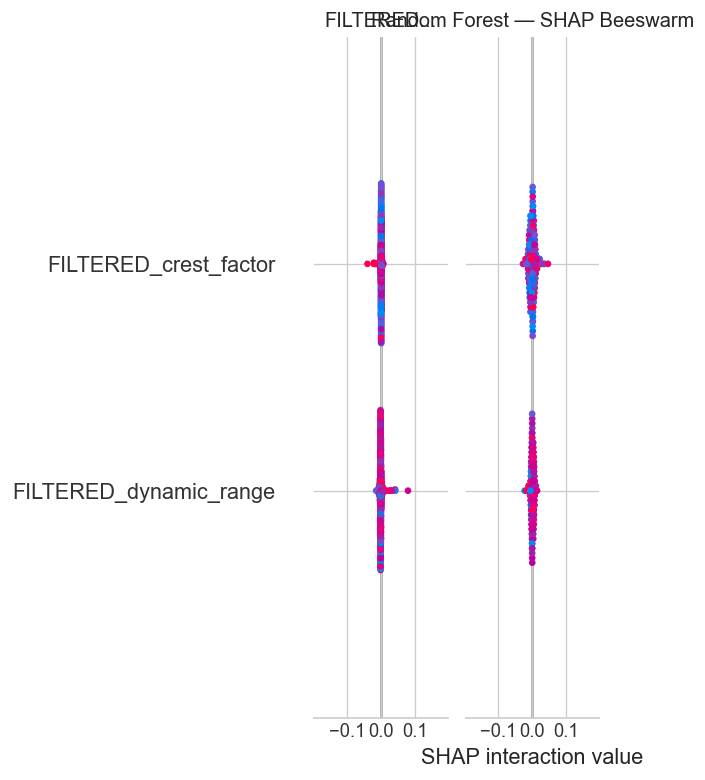

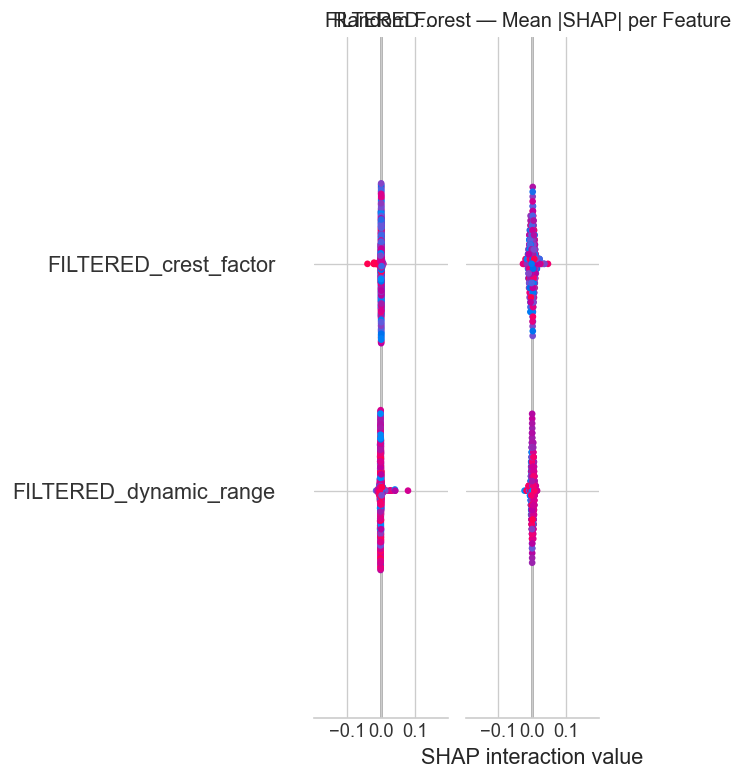

In [ ]:
# SHAP — Random Forest (TreeExplainer: exact, fast)
explainer_rf = shap.TreeExplainer(rf)
shap_rf      = explainer_rf(X_raw)
# sklearn RF returns [class0_shap, class1_shap] for binary classification
shap_rf_pos  = shap_rf[1] if isinstance(shap_rf, list) else shap_rf

shap.summary_plot(shap_rf, X_raw, feature_names=short_names,
                  plot_size=(10, max(4, len(short_names) * 0.22)), show=False)
plt.title('Random Forest — SHAP Beeswarm')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_rf, X_raw, feature_names=short_names, plot_type='bar',
                  plot_size=(8, max(4, len(short_names) * 0.22)), show=False)
plt.title('Random Forest — Mean |SHAP| per Feature')
plt.tight_layout()
plt.show()

## XGBoost

OOF probabilities via `cross_val_predict`.

XGBoost  CV Accuracy: 96.42% ± 1.47%

Feature Importances:
                                feature  importance
                     RAW_peak_amplitude    0.184611
                  RAW_spectral_flatness    0.154489
               RAW_spectral_centroid_hz    0.078409
                       RAW_total_energy    0.041172
      FILTERED_energy_concentration_pct    0.037170
          FILTERED_envelope_compactness    0.028237
                            RAW_fwhm_ms    0.027737
          FILTERED_spectral_centroid_hz    0.026892
                       FILTERED_fwhm_ms    0.026374
                      RAW_dynamic_range    0.025522
              FILTERED_peak_floor_ratio    0.025516
                FILTERED_peak_amplitude    0.024262
               RAW_secondary_peak_count    0.024207
               RAW_envelope_compactness    0.024026
                       RAW_rise_time_ms    0.021938
     RAW_secondary_peak_amplitude_ratio    0.021555
         FILTERED_spectral_bandwidth_hz    0.017821
     

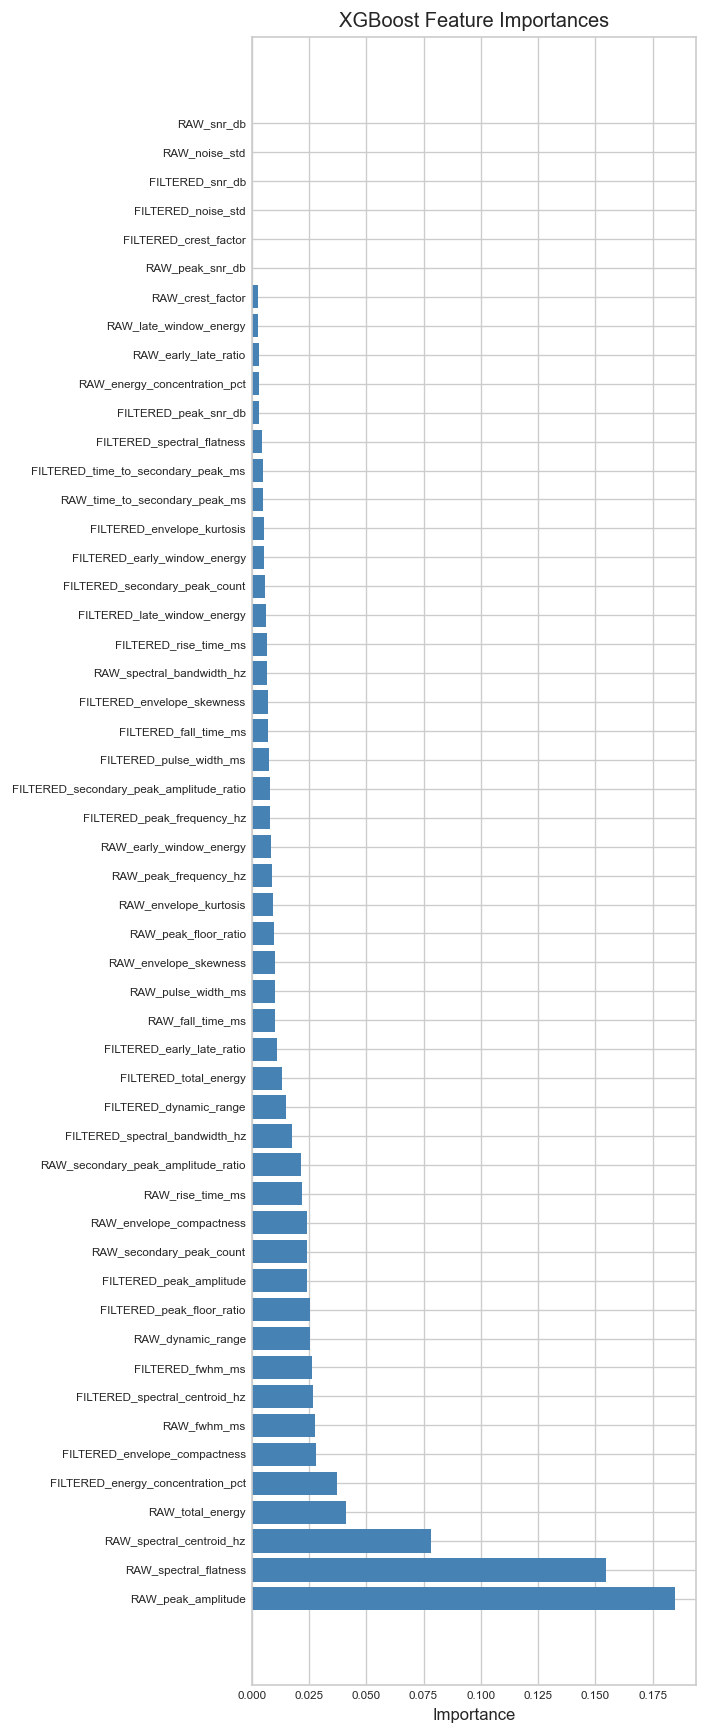

XGBoost (OOF)  |  BCE (log-loss): 0.0926   Brier Score: 0.0262


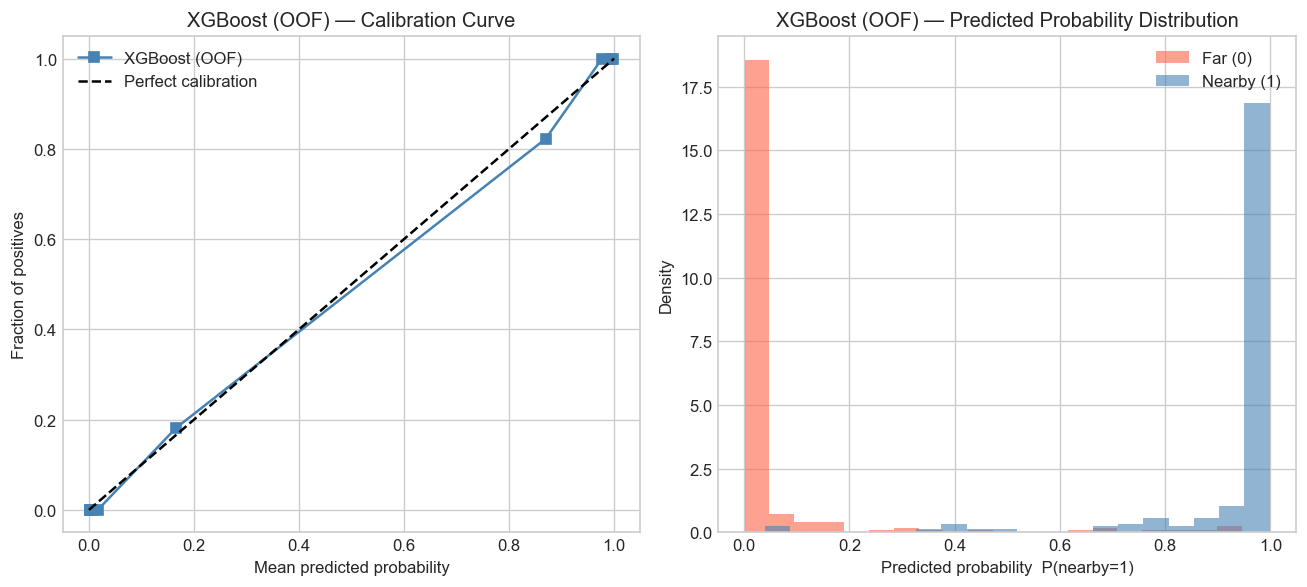

In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
)
xgb_model.fit(X_raw, y)

cv_xgb     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_scores = cross_val_score(xgb_model, X_raw, y, cv=cv_xgb, scoring='accuracy')
print(f'XGBoost  CV Accuracy: {xgb_scores.mean():.2%} ± {xgb_scores.std():.2%}')

xgb_imp = pd.DataFrame({'feature': short_names, 'importance': xgb_model.feature_importances_})
xgb_imp = xgb_imp.sort_values('importance', ascending=False)
print('\nFeature Importances:')
print(xgb_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, max(4, len(short_names) * 0.28)))
ax.barh(xgb_imp['feature'], xgb_imp['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importances')
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

xgb_prob = cross_val_predict(xgb_model, X_raw, y, cv=cv_xgb, method='predict_proba')[:, 1]
evaluate_model('XGBoost (OOF)', y, xgb_prob)

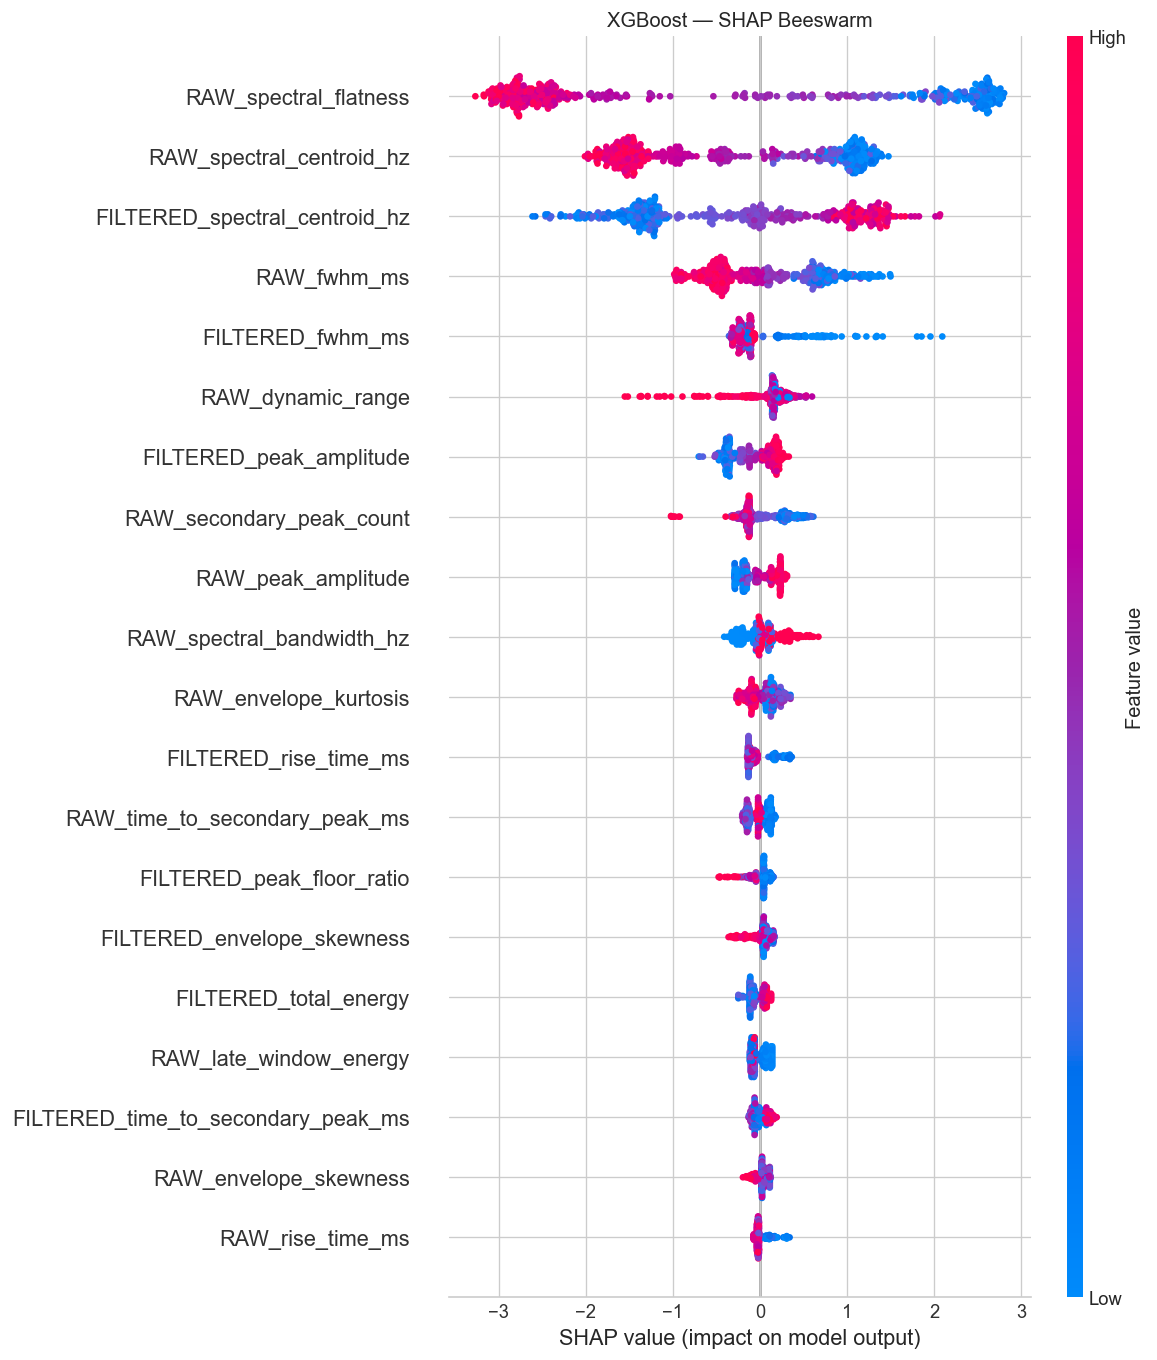

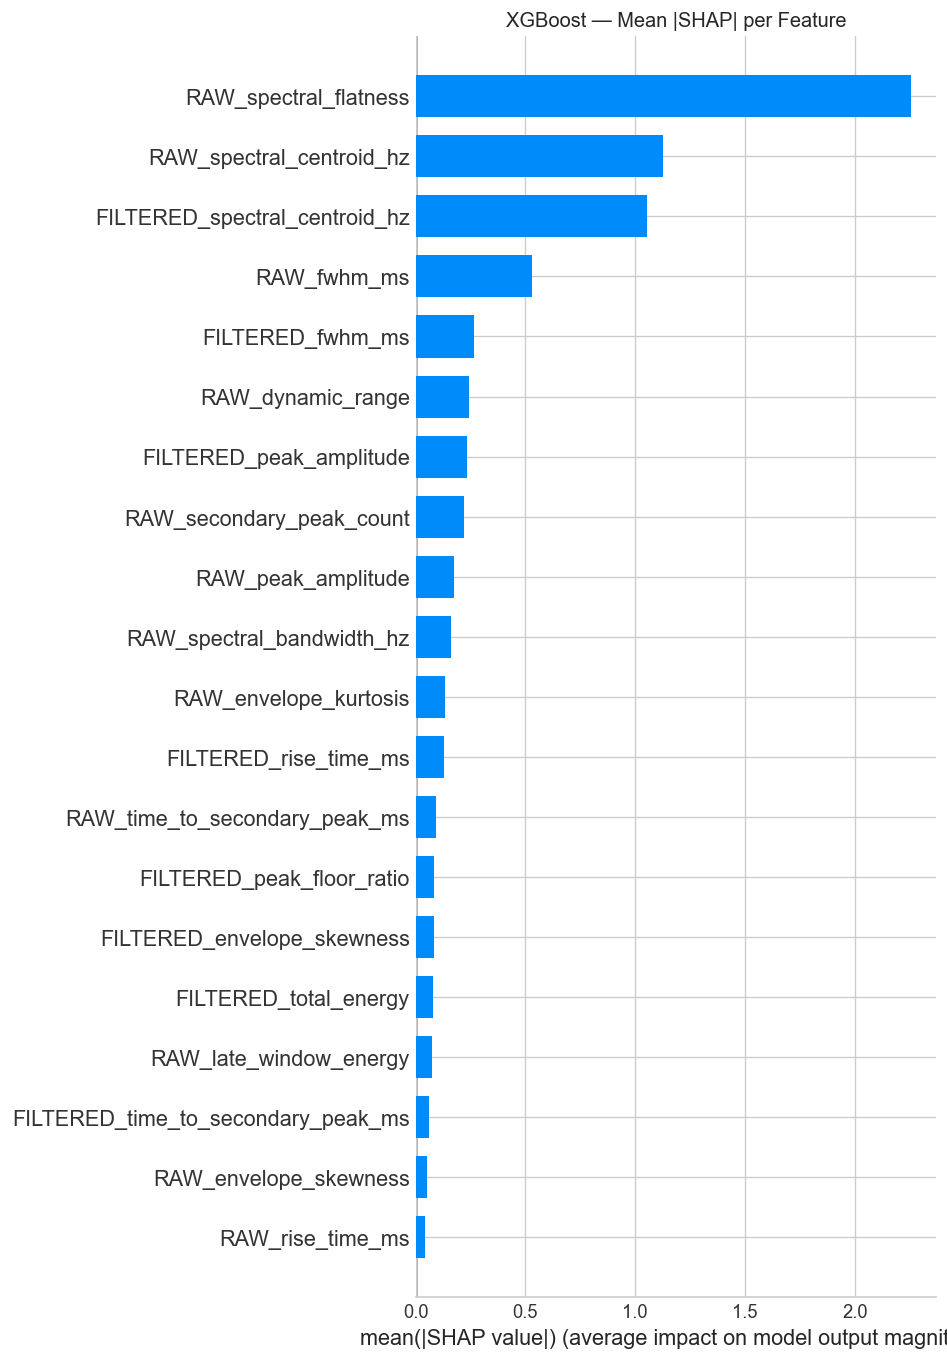

In [14]:
# SHAP — XGBoost (TreeExplainer: exact, fast)
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_xgb      = explainer_xgb(X_raw)

shap.summary_plot(shap_xgb, X_raw, feature_names=short_names,
                  plot_size=(10, max(4, len(short_names) * 0.22)), show=False)
plt.title('XGBoost — SHAP Beeswarm')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_xgb, X_raw, feature_names=short_names, plot_type='bar',
                  plot_size=(8, max(4, len(short_names) * 0.22)), show=False)
plt.title('XGBoost — Mean |SHAP| per Feature')
plt.tight_layout()
plt.show()